# Desafio Lighthouse 2026.2 (LH Nautical)

Este notebook reúne o raciocínio das questões Q1 a Q7: o que cada questão pedia, o caminho escolhido, os pontos de atenção, a consulta ou o código executado e o resultado com uma leitura do que ele significa pro negócio.

A entrega oficial de cada questão está em `../Submissão/Qx/`. A Q2 e a Q3 alteram o banco de dados (criam o schema e carregam os dados), então rodam pelo terminal antes deste notebook abrir. Aqui elas entram só como conferência do banco já processado. Já na Q4 e na Q5, a consulta SQL foi trazida direto pras células, porque isso ajuda a expor o passo a passo do raciocínio.

A lógica geral do trabalho foi: antes de buscar qualquer insight, construir confiança na base. Por isso as três primeiras questões tratam de entender a origem dos dados, definir como cada campo deveria ser armazenado e validar a carga, só depois entram as análises de negócio, a previsão e a recomendação.

Ordem de execução: este notebook já espera que o schema (Q2) e a carga (Q3) tenham rodado antes, pelo terminal. Os detalhes estão no `../README.md`.

## Configuração

In [1]:
import pandas as pd
import psycopg2

# As credenciais vêm das variáveis de ambiente padrão do PostgreSQL
# (PGHOST, PGPORT, PGDATABASE, PGUSER, PGPASSWORD), nunca ficam no código.
pg = psycopg2.connect()


def consultar(sql_texto):
    # Uso o cursor puro do psycopg2 aqui pra evitar o aviso do pandas sobre a
    # conexão não ser SQLAlchemy, sem precisar adicionar mais uma dependência.
    with pg.cursor() as cursor:
        cursor.execute(sql_texto)
        colunas = [descricao[0] for descricao in cursor.description]
        return pd.DataFrame(cursor.fetchall(), columns=colunas)

## Q1: EDA da tabela `orders`

O Sr. Almir quer saber se dá pra confiar nos dados de `orders` antes de qualquer decisão. Essa questão pede uma EDA simples: quantidade de linhas e colunas, intervalo de datas, estatísticas de `total` e um diagnóstico sobre a qualidade dos dados.

Foi feita uma inspeção inicial em pandas, direto no CSV bruto, pra ter uma visão geral da tabela. Em seguida, eu rodei a consulta SQL da Q1.1 no mesmo PostgreSQL usado nas questões seguintes, sem precisar de nenhuma outra ferramenta.

Um ponto de atenção: `COUNT(*)` conta linha, não coluna. Pra contar coluna corretamente em SQL, usou-se `information_schema.columns`, filtrando pelo schema atual.

### Inspeção inicial em pandas

In [2]:
orders_csv = pd.read_csv("../data/raw/1-lh_nautical_csv/orders.csv")
print("linhas, colunas:", orders_csv.shape)
orders_csv.head()

linhas, colunas: (48998, 13)


,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
1,2,SO-000002,ecommerce,618,9.0,4,paid,53199.05,0.00,53199.05,2023-02-03 04:36:21,2023-02-03 04:36:21,2023-02-03 04:36:21
2,3,SO-000003,pos,227,10.0,4,confirmed,17157.39,0.00,17157.39,2024-12-30 07:15:17,2024-12-30 07:15:17,2024-12-30 07:15:17
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
4,5,SO-000005,ecommerce,426,9.0,2,confirmed,32842.03,0.00,32842.03,2020-03-27 13:52:12,2020-03-27 13:52:12,2020-03-27 13:52:12


In [3]:
print("nulos por coluna:")
print(orders_csv.isnull().sum())
print("\nid duplicado:", orders_csv["id"].duplicated().sum())
print("order_number duplicado:", orders_csv["order_number"].duplicated().sum())

nulos por coluna:
id                     0
order_number           0
channel                0
customer_id            0
salesperson_id     24131
location_id            0
status                 0
subtotal               0
discount_amount        0
total                  0
placed_at              0
created_at             0
updated_at             0
dtype: int64

id duplicado: 0
order_number duplicado: 0


### A consulta da Q1.1, no PostgreSQL

In [4]:
with open("../Submissão/Q1/1.1.sql") as f:
    query_q1 = f.read()

consultar(query_q1)

,total_linhas,total_colunas,data_minima,data_maxima,total_minimo,total_maximo,total_medio
0,48998,13,2020-01-01 01:19:28,2026-12-31 23:43:09,32.62,127262.02,28704.992077227642


**Resultado:** 48.998 linhas, 13 colunas, `created_at` entre 2020-01-01 e 2026-12-31, `total` variando de R$ 32,62 a R$ 127.262,02, com média de R$ 28.704,99. Não há nulo nas colunas essenciais nem duplicidade em `id` ou `order_number`.

A resposta da Q1.2 (valor médio de `total`) é R$ 28.704,99.

Pro diagnóstico da Q1.3 (texto completo em `../Submissão/Q1/1.3.md`): os valores mais altos de `total` são plausíveis pra uma loja que vende motor de popa e embarcação. Confirmar isso exige relacionar com `order_items` e checar se são pedidos legítimos de grande porte. O único nulo relevante é `salesperson_id`, concentrado no canal `ecommerce`, mas sem ser uma regra fechada (30% dos pedidos do próprio ecommerce têm vendedor preenchido). A tabela está pronta pra essas agregações simples; pra análises de negócio das próximas questões, ainda falta confirmar a consistência das demais tabelas e decidir o que fazer com pedidos `cancelled` e `draft`.

## Q2: Schema

O trabalho aqui foi ler os 24 CSVs e gerar um `schema.sql` (o DDL do PostgreSQL), com um `CREATE TABLE` por arquivo, usando só a biblioteca padrão do Python.

O caminho adotado foi avaliar cada coluna em dois passos. Primeiro, verificar se ela está numa lista curta de exceções: colunas que parecem número mas na verdade são identificador, como CPF, chave de nota fiscal, código NCM ou código de barras. Não estando na lista, todos os valores são varridos pra decidir entre vazio, booleano, inteiro, decimal, data, timestamp ou texto. O script completo está em `../Submissão/Q2/infer_schema.py` e já rodou pelo terminal antes deste notebook (o `../README.md` explica a ordem).

A parte mais delicada da inferência: um campo só com dígitos nem sempre representa um número. `employees.cpf` e `products.ncm_code`, por exemplo, virariam `BIGINT` sem essa lista de exceções, porque nos dados atuais nenhum valor tem zero à esquerda. Isso é coincidência da amostra e pode mudar no próximo lote. Qualquer linha com zero à esquerda já bloqueia o tipo numérico automaticamente, mesmo sem entrar na lista, foi o que aconteceu com o CEP em `addresses` e `locations`.

### Conferindo o schema já criado

In [5]:
consultar(
    "SELECT COUNT(*) AS total_tabelas FROM information_schema.tables WHERE table_schema = current_schema()"
)

,total_tabelas
0,24


In [6]:
consultar(
    """
    SELECT table_name, column_name, data_type
    FROM information_schema.columns
    WHERE (table_name, column_name) IN (
        ('customers', 'tax_id'),
        ('employees', 'cpf'),
        ('products', 'ncm_code'),
        ('fiscal_invoices', 'nfe_access_key'),
        ('fiscal_invoices', 'series'),
        ('product_variants', 'barcode_ean'),
        ('product_variants', 'sale_price')
    )
    ORDER BY table_name, column_name
    """
)

,table_name,column_name,data_type
0,customers,tax_id,text
1,employees,cpf,text
2,fiscal_invoices,nfe_access_key,text
3,fiscal_invoices,series,text
4,product_variants,barcode_ean,text
5,product_variants,sale_price,numeric
6,products,ncm_code,text


**Resultado:** 24 tabelas no total. Os identificadores sensíveis (CPF, chave de NF-e, série, código de barras, código NCM) ficaram como `text`, e `sale_price` ficou como `numeric`, nenhum virou número inteiro por engano.

Isso confirma que a regra de inferência funcionou nos casos mais delicados: colunas que são só dígitos, mas representam documento ou código (não quantidade), ficaram como texto, preservando qualquer zero à esquerda existente. Colunas de preço e taxa ficaram numéricas, prontas pra soma e média nas próximas questões.

## Q3: Carregamento

Essa questão pede carregar os 24 CSVs no schema da Q2, sem nenhum tratamento, sem remover nulo, sem corrigir caractere especial.

Escolhi `COPY FROM STDIN` (em vez de `INSERT` ou do `COPY` do lado do servidor), com as colunas declaradas na mesma ordem do cabeçalho do CSV. As 24 tabelas carregam dentro de uma única transação, o `COMMIT` só acontece depois de reconciliar a contagem de cada tabela contra o CSV de origem. O código completo fica em `../Submissão/Q3/load_data.py`, que também já rodou pelo terminal.

O schema da Q2 não tem chave única, de propósito, por ser uma camada bruta, e isso traz um risco real: rodar a carga duas vezes duplicaria os dados silenciosamente. Por isso eu deixei o script recusar rodar se o destino já tiver alguma linha, em vez de duplicar sem avisar.

### Conferindo a carga já feita

In [7]:
contagem_q3_2 = consultar(
    """
    SELECT 'customers' AS tabela, COUNT(*) AS linhas FROM customers
    UNION ALL SELECT 'orders', COUNT(*) FROM orders
    UNION ALL SELECT 'order_items', COUNT(*) FROM order_items
    UNION ALL SELECT 'payments', COUNT(*) FROM payments
    """
)
contagem_q3_2

,tabela,linhas
0,customers,2000
1,payments,53546
2,orders,48998
3,order_items,147320


In [8]:
print("Q3.2 (customers + orders + order_items + payments):", contagem_q3_2["linhas"].sum())

Q3.2 (customers + orders + order_items + payments): 251864


**Resultado:** `customers` com 2.000 linhas, `orders` com 48.998, `order_items` com 147.320, `payments` com 53.546, somando **251.864** (resposta da Q3.2, em `../Submissão/Q3/3.2.md`). No total, as 24 tabelas somam 433.424 linhas, igual à soma dos 24 CSVs originais, sem divergência em nenhuma.

A contagem bateu exatamente com o CSV de origem em todas as tabelas. Conferir tabela por tabela, e não só o total geral, é o que garante que a carga não perdeu nem duplicou nenhuma linha, uma falta numa tabela poderia ficar escondida atrás de um excesso em outra. Essa reconciliação sustenta a confiabilidade da etapa: a prova de que a base persistida preservou exatamente a origem dos dados.

## Q4: Análise de Clientes

O objetivo foi identificar os 10 clientes com maior ticket médio entre os que compraram de 13 categorias diferentes pra cima e depois descobrir qual categoria esses 10 mais compraram em quantidade de item.

`orders` tem uma linha por pedido, `order_items` tem uma linha por item. Por isso, faturamento, frequência e ticket médio foram calculados numa consulta que olha só `orders`, e a diversidade de categoria numa consulta separada, pela cadeia até o produto (`orders → order_items → product_variants → products`). As duas se juntam depois, pelo `customer_id`.

Se faturamento e frequência fossem calculados depois do `JOIN` com `order_items` (necessário pra chegar em categoria), um pedido de 3 itens contaria 3 vezes, inflando os dois números.

### A consulta

In [9]:
top_10 = consultar(
    """
    WITH metricas_pedidos AS (
        SELECT
            customer_id,
            SUM(total) AS faturamento_total,
            COUNT(id) AS frequencia,
            SUM(total) / COUNT(id) AS ticket_medio
        FROM orders
        GROUP BY customer_id
    ),
    diversidade_clientes AS (
        SELECT
            o.customer_id,
            COUNT(DISTINCT p.category_id) AS diversidade_categorias
        FROM orders o
        JOIN order_items oi ON oi.order_id = o.id
        JOIN product_variants pv ON pv.id = oi.product_variant_id
        JOIN products p ON p.id = pv.product_id
        GROUP BY o.customer_id
    )
    SELECT
        mp.customer_id,
        ROUND(mp.faturamento_total, 2) AS faturamento_total,
        mp.frequencia,
        ROUND(mp.ticket_medio, 2) AS ticket_medio,
        dc.diversidade_categorias
    FROM metricas_pedidos mp
    JOIN diversidade_clientes dc ON dc.customer_id = mp.customer_id
    WHERE dc.diversidade_categorias >= 13
    ORDER BY mp.ticket_medio DESC, mp.customer_id ASC
    LIMIT 10
    """
)

top_10

,customer_id,faturamento_total,frequencia,ticket_medio,diversidade_categorias
0,22,1087838.44,26,41839.94,14
1,1477,916262.58,22,41648.30,14
2,929,1082775.89,26,41645.23,14
3,1116,655737.20,16,40983.58,14
4,1691,815471.30,20,40773.57,14
5,774,726127.99,18,40340.44,14
6,1470,1040553.09,26,40021.27,14
7,1599,997616.46,25,39904.66,14
8,965,677297.78,17,39841.05,14
9,1722,1146455.22,29,39532.94,14


In [10]:
categoria_top10 = consultar(
    """
    WITH metricas_pedidos AS (
        SELECT customer_id, SUM(total) / COUNT(id) AS ticket_medio
        FROM orders
        GROUP BY customer_id
    ),
    diversidade_clientes AS (
        SELECT o.customer_id, COUNT(DISTINCT p.category_id) AS diversidade_categorias
        FROM orders o
        JOIN order_items oi ON oi.order_id = o.id
        JOIN product_variants pv ON pv.id = oi.product_variant_id
        JOIN products p ON p.id = pv.product_id
        GROUP BY o.customer_id
    ),
    top_10 AS (
        SELECT mp.customer_id
        FROM metricas_pedidos mp
        JOIN diversidade_clientes dc ON dc.customer_id = mp.customer_id
        WHERE dc.diversidade_categorias >= 13
        ORDER BY mp.ticket_medio DESC, mp.customer_id ASC
        LIMIT 10
    )
    SELECT
        c.id AS category_id,
        c.name AS categoria,
        SUM(oi.quantity) AS quantidade_total
    FROM top_10 t
    JOIN orders o ON o.customer_id = t.customer_id
    JOIN order_items oi ON oi.order_id = o.id
    JOIN product_variants pv ON pv.id = oi.product_variant_id
    JOIN products p ON p.id = pv.product_id
    JOIN categories c ON c.id = p.category_id
    GROUP BY c.id, c.name
    ORDER BY quantidade_total DESC, category_id ASC
    """
)

categoria_top10

,category_id,categoria,quantidade_total
0,8,Hélices,492
1,3,Coletes Salva-Vidas,393
2,5,Eletrônica Náutica,392
3,7,Âncoras,387
4,10,Iluminação,333
5,12,Manutenção,330
6,13,SEGURANÇA,325
7,6,Velas,313
8,11,Pintura Marítima,307
9,9,Acessórios de Convés,305


**Resultado:** os 10 clientes com maior ticket médio, todos com diversidade 14. A categoria líder entre esses 10 é **Hélices** (`category_id = 8`), com 492 itens, a segunda colocada (Coletes Salva-Vidas, com 393) fica bem atrás.

Essa restrição ao Top 10 vem da ordem das operações: os 10 `customer_id` ficam isolados numa CTE antes de qualquer coisa, e a segunda consulta parte dela, então nenhum pedido de cliente fora do ranking entra na soma de quantidade. A lição maior aqui é que um ranking só é confiável quando cada métrica é calculada no nível em que ela realmente existe, faturamento no pedido, categoria no item. Detalhe completo em `../Submissão/Q4/4.2.md`.

## Q5: Dimensão de Calendário

O Sr. Almir quer saber qual dia da semana tem a pior média de vendas nas lojas físicas (`channel = 'pos'`), pra decidir se vale fechar a loja nesse dia.

Um estagiário fictício do enunciado agrupou direto os pedidos físicos e concluiu que Domingo era ótimo. O problema é que os dias em que a loja abriu e não vendeu nada não aparecem entre as vendas `pos` agregadas: a data some da agregação, e o valor não vira zero sozinho. Pra corrigir isso, foi construída uma dimensão de calendário com `generate_series`, uma linha pra cada data entre o `MIN` e o `MAX` de `placed_at::date` observados no arquivo (não `CURRENT_DATE`, pra manter a consulta reproduzível independente de quando ela roda).

Dois detalhes resolveram isso: o `LEFT JOIN` precisa partir do calendário, não das vendas, e o `COALESCE(venda_diaria, 0)` precisa vir antes da média, porque `AVG()` ignora `NULL` mas não trata `NULL` como zero. Sem isso, os dias sem venda ficariam fora do cálculo e o erro do estagiário se repetiria.

### A consulta

In [11]:
calendario_semana = consultar(
    """
    WITH limites AS (
        SELECT MIN(placed_at::date) AS data_inicial, MAX(placed_at::date) AS data_final
        FROM orders
    ),
    datas AS (
        SELECT generate_series(data_inicial, data_final, INTERVAL '1 day')::date AS data
        FROM limites
    ),
    calendario AS (
        SELECT
            data,
            EXTRACT(ISODOW FROM data)::int AS numero_dia_semana,
            CASE EXTRACT(ISODOW FROM data)::int
                WHEN 1 THEN 'Segunda-feira' WHEN 2 THEN 'Terça-feira' WHEN 3 THEN 'Quarta-feira'
                WHEN 4 THEN 'Quinta-feira' WHEN 5 THEN 'Sexta-feira' WHEN 6 THEN 'Sábado'
                WHEN 7 THEN 'Domingo'
            END AS dia_semana
        FROM datas
    ),
    vendas_diarias AS (
        SELECT placed_at::date AS data, SUM(total) AS venda_diaria
        FROM orders
        WHERE channel = 'pos'
        GROUP BY placed_at::date
    ),
    calendario_com_vendas AS (
        SELECT c.data, c.numero_dia_semana, c.dia_semana, COALESCE(v.venda_diaria, 0) AS venda_diaria
        FROM calendario c
        LEFT JOIN vendas_diarias v ON v.data = c.data
    )
    SELECT
        numero_dia_semana,
        dia_semana,
        COUNT(*) AS dias_no_calendario,
        COUNT(*) FILTER (WHERE venda_diaria = 0) AS dias_sem_venda,
        ROUND(AVG(venda_diaria), 2) AS media_vendas_diarias
    FROM calendario_com_vendas
    GROUP BY numero_dia_semana, dia_semana
    ORDER BY media_vendas_diarias ASC, numero_dia_semana ASC
    """
)

calendario_semana

,numero_dia_semana,dia_semana,dias_no_calendario,dias_sem_venda,media_vendas_diarias
0,4,Quinta-feira,366,20,157154.32
1,7,Domingo,365,12,157616.13
2,1,Segunda-feira,365,7,158241.15
3,6,Sábado,365,11,164858.27
4,2,Terça-feira,365,8,166118.83
5,5,Sexta-feira,365,10,170193.68
6,3,Quarta-feira,366,10,173605.44


**Resultado:** o pior dia é **Quinta-feira**, com média de R$ 157.154,32 (20 das 366 quintas do período sem nenhuma venda física). Domingo, que o estagiário achou que era ótimo, fica em segundo lugar entre os piores, não em primeiro entre os melhores.

A diferença entre contar só os dias com venda e contar todos os dias do calendário é o que muda a resposta: sem os zeros, a Quinta-feira pareceria bem melhor do que realmente é. O insight real está em outro lugar: ausência de linha também é informação, e a operação precisa ser avaliada sobre todos os dias do calendário, inclusive os que não venderam nada. Sozinho, esse resultado não prova que fechar a loja nesse dia é a melhor decisão, isso exigiria considerar custo fixo, margem e sazonalidade também. Detalhe completo em `../Submissão/Q5/5.2.md`.

## Q6: Previsão de Demanda

Essa questão pede prever a quantidade mensal vendida do produto "Bússola de Bordo 702" para janeiro, fevereiro e março de 2026, usando um baseline obrigatório (média móvel dos 3 meses anteriores), e comparar com o real via MAE.

Diferente da Q1, Q4 e Q5, aqui não há SQL, o enunciado pede pra unir `products`, `product_variants`, `order_items` e `orders` direto em pandas. A quantidade vendida por mês vem de `SUM(order_items.quantity)`, nunca de contagem de pedidos. A previsão é walk-forward: cada mês usa só os 3 meses com data estritamente anterior a ele. Fevereiro e março podem usar valores reais de 2026 já fechados no momento em que a previsão seria feita, porque a avaliação simula uma atualização mensal do baseline. Implementação em `../Submissão/Q6/6.1.py`.

Um detalhe decisivo: o nome "Bússola de Bordo 702" existe em **dois** registros de `products.csv` (`product_id` 74 e 240, de marca e categoria diferentes), com três variantes ao todo. Selecionar só o primeiro resultado (`.iloc[0]`) descartaria parte real das vendas do produto, por isso eu mantive as duas correspondências. E, como na Q5, um mês sem venda no histórico (outubro de 2020) precisa existir como zero, senão a janela de 3 meses deixa de representar meses consecutivos do calendário.

### Montando o dataset unificado

In [12]:
NOME_PRODUTO_Q6 = "Bússola de Bordo 702"

products_csv = pd.read_csv("../data/raw/1-lh_nautical_csv/products.csv")
variants_csv = pd.read_csv("../data/raw/1-lh_nautical_csv/product_variants.csv")
items_csv = pd.read_csv("../data/raw/1-lh_nautical_csv/order_items.csv")
orders_q6_csv = pd.read_csv("../data/raw/1-lh_nautical_csv/orders.csv", parse_dates=["placed_at"])

# Filtrar pelo nome exato mantém os dois product_id. Evitei usar .iloc[0] ou
# fixar um product_id manualmente, porque isso descartaria um dos dois.
produtos_alvo = products_csv.loc[products_csv["name"] == NOME_PRODUTO_Q6, ["id", "name"]].rename(
    columns={"id": "product_id"}
)
print("product_id encontrados:", sorted(produtos_alvo["product_id"]))

variantes_q6 = variants_csv.loc[:, ["id", "product_id"]].rename(columns={"id": "product_variant_id"})
itens_q6 = items_csv.loc[:, ["order_id", "product_variant_id", "quantity"]]
pedidos_q6 = orders_q6_csv.loc[:, ["id", "placed_at"]].rename(columns={"id": "order_id"})

unificado_q6 = pd.merge(produtos_alvo, variantes_q6, on="product_id", how="inner")
print("product_variant_id relacionados:", sorted(unificado_q6["product_variant_id"]))

unificado_q6 = pd.merge(unificado_q6, itens_q6, on="product_variant_id", how="inner")
unificado_q6 = pd.merge(unificado_q6, pedidos_q6, on="order_id", how="inner")

print(
    "dataset unificado:", unificado_q6.shape[0], "linhas,",
    unificado_q6["order_id"].nunique(), "pedidos distintos",
)

product_id encontrados: [74, 240]
product_variant_id relacionados: [147, 148, 486]
dataset unificado: 472 linhas, 470 pedidos distintos


In [13]:
FIM_TREINO_Q6 = pd.Timestamp("2025-12-01")
INICIO_TESTE_Q6 = pd.Timestamp("2026-01-01")
FIM_TESTE_Q6 = pd.Timestamp("2026-03-01")

unificado_q6["month"] = unificado_q6["placed_at"].dt.to_period("M").dt.to_timestamp()

# Nada depois de março/2026 entra na análise. A base tem pedidos até
# dezembro/2026, mas o teste termina no primeiro trimestre.
unificado_q6 = unificado_q6[unificado_q6["month"] <= FIM_TESTE_Q6]

vendas_mensais_q6 = unificado_q6.groupby("month", as_index=False)["quantity"].sum()

# Completo os meses sem venda com zero, senão o tail(3) pularia meses
# ausentes e a janela de 3 meses deixaria de fazer sentido.
todos_os_meses_q6 = pd.date_range(vendas_mensais_q6["month"].min(), FIM_TESTE_Q6, freq="MS")
vendas_mensais_q6 = (
    vendas_mensais_q6.set_index("month")
    .reindex(todos_os_meses_q6, fill_value=0)
    .rename_axis("month")
    .reset_index()
)

print(
    "meses sem venda no histórico:",
    vendas_mensais_q6.loc[vendas_mensais_q6["quantity"] == 0, "month"].dt.date.tolist(),
)

meses sem venda no histórico: [datetime.date(2020, 10, 1)]


In [14]:
treino_q6 = vendas_mensais_q6.loc[vendas_mensais_q6["month"] <= FIM_TREINO_Q6]
print(
    "treino:", treino_q6["month"].min().date(), "a", treino_q6["month"].max().date(),
    f"({len(treino_q6)} meses)",
)

teste_q6 = vendas_mensais_q6.loc[
    vendas_mensais_q6["month"].between(INICIO_TESTE_Q6, FIM_TESTE_Q6)
].reset_index(drop=True)

# Walk-forward: cada previsão usa só os 3 meses com "month" estritamente
# anterior ao mês previsto, nunca o próprio mês nem um mês futuro.
previsoes_q6 = []
for mes_previsto in teste_q6["month"]:
    tres_meses_anteriores = vendas_mensais_q6.loc[vendas_mensais_q6["month"] < mes_previsto].tail(3)
    previsoes_q6.append(tres_meses_anteriores["quantity"].mean())

teste_q6["forecast"] = previsoes_q6
teste_q6["absolute_error"] = (teste_q6["quantity"] - teste_q6["forecast"]).abs()

teste_q6

treino: 2020-01-01 a 2025-12-01 (72 meses)


,month,quantity,forecast,absolute_error
0,2026-01-01,79,38.666667,40.333333
1,2026-02-01,68,53.666667,14.333333
2,2026-03-01,60,56.333333,3.666667


In [15]:
mae_q6 = teste_q6["absolute_error"].mean()
total_previsto_q6 = teste_q6["forecast"].sum()
total_previsto_q6_arredondado = round(total_previsto_q6)

print(f"MAE: {mae_q6:.4f}")
print(f"soma das previsões (sem arredondar): {total_previsto_q6:.4f}")
print(f"Q6.2 (soma arredondada): {total_previsto_q6_arredondado}")

MAE: 19.4444
soma das previsões (sem arredondar): 148.6667
Q6.2 (soma arredondada): 149


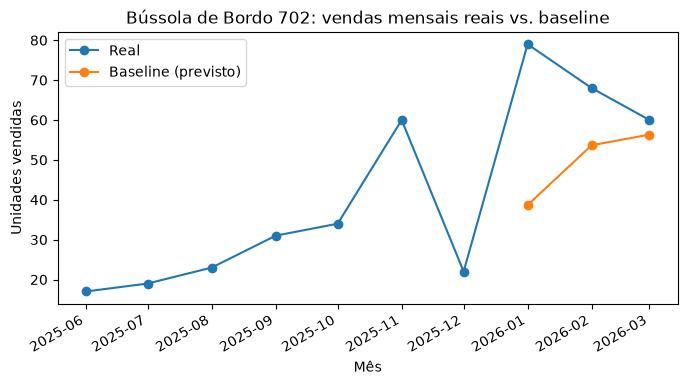

In [16]:
import matplotlib.pyplot as plt

historico_q6 = vendas_mensais_q6[vendas_mensais_q6["month"] >= "2025-06-01"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historico_q6["month"], historico_q6["quantity"], marker="o", label="Real")
ax.plot(teste_q6["month"], teste_q6["forecast"], marker="o", label="Baseline (previsto)")
ax.set_title("Bússola de Bordo 702: vendas mensais reais vs. baseline")
ax.set_xlabel("Mês")
ax.set_ylabel("Unidades vendidas")
ax.legend()
fig.autofmt_xdate()
plt.show()

**Resultado:** dois `product_id` (74 e 240), três `product_variant_id` (147, 148, 486), dataset unificado com 472 linhas e 470 pedidos distintos. As previsões walk-forward: janeiro 38,6667, fevereiro 53,6667, março 56,3333, somando **148,6667**, que arredondado dá **149** (`../Submissão/Q6/6.2.md`). O MAE ficou em **19,4444** unidades.

As três previsões ficaram abaixo do valor real do trimestre, com o maior erro em janeiro (real 79, previsto 38,6667). O baseline serve como referência inicial de comparação, mas não seria usado sozinho pra automatizar decisão de compra: subestimou o trimestre inteiro, reage com atraso e não representa tendência, sazonalidade ou mudanças bruscas de demanda. Faz mais sentido como ponto de partida acompanhado de análise de contexto do que como decisão automática. Explicação completa, incluindo como o vazamento temporal foi evitado, está em `../Submissão/Q6/6.3.md`.

## Q7: Sistema de Recomendação

A Marina quer uma vitrine "quem comprou isso, também levou...", recomendando o produto mais similar ao "Motor de Popa 1949" com base no comportamento de compra dos clientes, deixando de fora categoria, marca e preço.

Foi montada uma matriz binária cliente por produto (presença ou ausência de compra, ignorando quantidade), e calculada a similaridade de cosseno entre as colunas com `sklearn.metrics.pairwise.cosine_similarity`, em vez de implementar a fórmula manualmente. Todos os pedidos entram, sem filtro de status, canal ou período, pelo mesmo motivo da Q6: o enunciado não define esse filtro, e inventar um mudaria o resultado. Código em `../Submissão/Q7/7.1.py`.

O cuidado principal foi que a matriz precisa ser transposta antes do `cosine_similarity`, sem o `.T` o sklearn compararia cliente com cliente, quando o que interessa é a comparação entre produtos. E o próprio produto precisa ficar fora do ranking pelo `product_id`: comparar a similaridade a `1` falharia, porque a similaridade de um produto com ele mesmo pode não dar exatamente `1.0` por ponto flutuante.

### Montando a matriz binária cliente por produto

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

NOME_PRODUTO_Q7 = "Motor de Popa 1949"

orders_q7 = pd.read_csv("../data/raw/1-lh_nautical_csv/orders.csv").rename(
    columns={"id": "order_id"}
)[["order_id", "customer_id"]]
items_q7 = pd.read_csv("../data/raw/1-lh_nautical_csv/order_items.csv")[
    ["order_id", "product_variant_id"]
]
variants_q7 = pd.read_csv("../data/raw/1-lh_nautical_csv/product_variants.csv").rename(
    columns={"id": "product_variant_id"}
)[["product_variant_id", "product_id"]]
products_q7 = pd.read_csv("../data/raw/1-lh_nautical_csv/products.csv").rename(
    columns={"id": "product_id"}
)[["product_id", "name"]]

alvo_q7 = products_q7[products_q7["name"] == NOME_PRODUTO_Q7]
assert len(alvo_q7) == 1, "esperado 1 produto único para o nome exato"
produto_alvo_id_q7 = int(alvo_q7.iloc[0]["product_id"])
print("product_id alvo:", produto_alvo_id_q7)

unificado_q7 = items_q7.merge(orders_q7, on="order_id").merge(variants_q7, on="product_variant_id")
print("linhas após os merges:", len(unificado_q7))
print("customer_id nulo:", unificado_q7["customer_id"].isnull().sum())
print("product_id nulo:", unificado_q7["product_id"].isnull().sum())

# Uma linha por par único de cliente e produto: comprar 1 vez ou N vezes dá
# o mesmo 1, só importa se comprou ou não.
interacoes_q7 = unificado_q7[["customer_id", "product_id"]].drop_duplicates()
print("pares únicos cliente-produto:", len(interacoes_q7))

matriz_q7 = pd.crosstab(interacoes_q7["customer_id"], interacoes_q7["product_id"])
matriz_q7 = (matriz_q7 > 0).astype(int)
print("formato da matriz:", matriz_q7.shape)
print("valores únicos na matriz:", sorted(int(v) for v in pd.unique(matriz_q7.values.ravel())))
print("compradores do alvo:", int(matriz_q7[produto_alvo_id_q7].sum()))

product_id alvo: 180
linhas após os merges: 147320
customer_id nulo: 0
product_id nulo: 0
pares únicos cliente-produto: 135508


formato da matriz: (2000, 500)
valores únicos na matriz: [0, 1]
compradores do alvo: 397


In [18]:
# O .T é essencial aqui: sem transpor, o sklearn compara cliente com cliente,
# não produto com produto.
similaridade_q7 = cosine_similarity(matriz_q7.T)
similaridade_q7 = pd.DataFrame(similaridade_q7, index=matriz_q7.columns, columns=matriz_q7.columns)
print("formato da matriz de similaridade:", similaridade_q7.shape)
print(
    "similaridade do alvo consigo mesmo (antes da exclusão):",
    similaridade_q7.loc[produto_alvo_id_q7, produto_alvo_id_q7],
)

formato da matriz de similaridade: (500, 500)
similaridade do alvo consigo mesmo (antes da exclusão): 0.9999999999999957


In [19]:
TOP_N_Q7 = 5

# Excluo o próprio produto pelo product_id, nunca comparando a similaridade a 1.
ranking_q7 = (
    similaridade_q7[produto_alvo_id_q7]
    .drop(index=produto_alvo_id_q7)
    .rename("similarity")
    .reset_index()
    .rename(columns={"index": "product_id"})
)
ranking_q7 = ranking_q7.sort_values(["similarity", "product_id"], ascending=[False, True]).head(TOP_N_Q7)
ranking_q7 = ranking_q7.merge(products_q7, on="product_id")[["product_id", "name", "similarity"]]

ranking_q7

,product_id,name,similarity
0,389,Motor de Popa 5331,0.256553
1,295,Cabo Náutico 2105,0.256239
2,75,Vela Mestra 1913,0.255785
3,337,Cabo Náutico 9048,0.239332
4,55,GPS Plotter 6249,0.237744


**Resultado:** matriz cliente por produto com formato `(2000, 500)`, só valores `{0, 1}` e 397 compradores do produto-alvo. A matriz de similaridade ficou `(500, 500)`. No top 5: Motor de Popa 5331 (0,256553), Cabo Náutico 2105 (0,256239), Vela Mestra 1913 (0,255785), Cabo Náutico 9048 (0,239332), GPS Plotter 6249 (0,237744), então **a resposta da Q7.2 é Motor de Popa 5331** (`../Submissão/Q7/7.2.md`).

As similaridades não são altas em valor absoluto, a maior é cerca de 0,26, o que é esperado num catálogo de 500 produtos: a questão pede o produto mais similar dentro do catálogo, sem piso de similaridade. Os 106 clientes que compraram tanto o Motor de Popa 1949 quanto o 5331 representam uma sobreposição relevante pro ranking, mesmo com a similaridade absoluta baixa. O que pesa aqui é a sobreposição relativa entre os grupos de compradores dentro do catálogo, medida que independe do volume absoluto de compras. O ranking reflete afinidade entre grupos de compradores dentro do catálogo. Pode apoiar campanhas e vitrines comerciais, mas não é prova de que um cliente vá comprar o produto recomendado. Explicação completa de como a matriz foi construída, o que a similaridade de cosseno significa aqui e uma limitação do método, está em `../Submissão/Q7/7.3.md`.

## Conclusão: arquitetura de dados do dashboard

O material complementar (o dashboard) não lê do PostgreSQL da Q2 e da Q3. O `gerar_dados.py`, em `../Submissão/Q8-Dashboard/`, lê os CSVs brutos diretamente e reproduz em pandas as mesmas regras já validadas nas Q4 a Q7, gerando seis extratos analíticos em `../data/processed/marts/dashboard/`. É um caminho de dados paralelo ao pipeline SQL, com a mesma origem e sem depender dele.

A organização para onde o desafio exige e não avança além disso. Não há `stage` nem `intermediate` porque `data/raw` já preserva a origem e a Q3 já materializa uma ingestão tipada no PostgreSQL. As transformações do dashboard são pequenas o bastante pra viver, de forma legível, dentro de um único script, e só o produto final consumido pelo Looker Studio precisa virar CSV. Os detalhes de granularidade, coluna e validação de cada extrato estão em `../Submissão/Q8-Dashboard/README.md`.

A principal entrega deste projeto é a sequência de decisões por trás dos números: dados brutos preservados, carga validada linha a linha, granularidade respeitada em cada métrica, limitações dos modelos explicitadas. É esse rastro que deixa o resultado aberto a quem quiser conferir por conta própria.

In [20]:
pg.close()